# NBA Shot Location Data (2004–2025) — Exploratory Data Analysis

## 1. Setup & Loading

In [1]:
import glob

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
DATA_DIR = "NBA_Shots_04_25"

csv_files = sorted(glob.glob(f"{DATA_DIR}/NBA_*_Shots.csv"))
print(f"Found {len(csv_files)} season files: {[f.split('/')[-1] for f in csv_files]}")

df = pd.concat(
    (pd.read_csv(f, low_memory=False) for f in csv_files),
    ignore_index=True,
)
print(f"\nTotal rows: {len(df):,}  |  Columns: {df.shape[1]}")

Found 22 season files: ['NBA_2004_Shots.csv', 'NBA_2005_Shots.csv', 'NBA_2006_Shots.csv', 'NBA_2007_Shots.csv', 'NBA_2008_Shots.csv', 'NBA_2009_Shots.csv', 'NBA_2010_Shots.csv', 'NBA_2011_Shots.csv', 'NBA_2012_Shots.csv', 'NBA_2013_Shots.csv', 'NBA_2014_Shots.csv', 'NBA_2015_Shots.csv', 'NBA_2016_Shots.csv', 'NBA_2017_Shots.csv', 'NBA_2018_Shots.csv', 'NBA_2019_Shots.csv', 'NBA_2020_Shots.csv', 'NBA_2021_Shots.csv', 'NBA_2022_Shots.csv', 'NBA_2023_Shots.csv', 'NBA_2024_Shots.csv', 'NBA_2025_Shots.csv']



Total rows: 4,450,789  |  Columns: 26


## 2. Pre-processing

In [3]:
df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"], format="%m-%d-%Y", errors="coerce")
df["SHOT_MADE"] = df["SHOT_MADE"].map({True: 1, False: 0, "TRUE": 1, "FALSE": 0}).astype("Int8")
df["SEASON_1"] = df["SEASON_1"].astype("int16")
df["SHOT_DISTANCE"] = pd.to_numeric(df["SHOT_DISTANCE"], errors="coerce")
df["LOC_X"] = pd.to_numeric(df["LOC_X"], errors="coerce")
df["LOC_Y"] = pd.to_numeric(df["LOC_Y"], errors="coerce")

cat_cols = [
    "TEAM_NAME", "PLAYER_NAME", "POSITION_GROUP", "POSITION",
    "EVENT_TYPE", "ACTION_TYPE", "SHOT_TYPE",
    "BASIC_ZONE", "ZONE_NAME", "ZONE_ABB", "ZONE_RANGE",
]
for c in cat_cols:
    df[c] = df[c].astype("category")

df["SECS_INTO_QUARTER"] = (3 - df["MINS_LEFT"]) * 60 + (60 - df["SECS_LEFT"])
df["IS_3PT"] = (df["SHOT_TYPE"] == "3PT Field Goal").astype("Int8")

print("dtypes after casting:")
print(df.dtypes.to_string())

dtypes after casting:
SEASON_1                      int16
SEASON_2                     object
TEAM_ID                       int64
TEAM_NAME                  category
PLAYER_ID                     int64
PLAYER_NAME                category
POSITION_GROUP             category
POSITION                   category
GAME_DATE            datetime64[ns]
GAME_ID                       int64
HOME_TEAM                    object
AWAY_TEAM                    object
EVENT_TYPE                 category
SHOT_MADE                      Int8
ACTION_TYPE                category
SHOT_TYPE                  category
BASIC_ZONE                 category
ZONE_NAME                  category
ZONE_ABB                   category
ZONE_RANGE                 category
LOC_X                       float64
LOC_Y                       float64
SHOT_DISTANCE                 int64
QUARTER                       int64
MINS_LEFT                     int64
SECS_LEFT                     int64
SECS_INTO_QUARTER             int64
IS_3PT

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing": missing, "pct": missing_pct})
print(missing_report[missing_report["missing"] > 0].to_string())

# drop rows where spatial coordinates are missing (unusable for shot charts)
before = len(df)
df = df.dropna(subset=["LOC_X", "LOC_Y", "SHOT_DISTANCE"])
print(f"\nDropped {before - len(df):,} rows with missing spatial data → {len(df):,} rows remaining")

                missing   pct
POSITION_GROUP   227457  5.11
POSITION         227457  5.11



Dropped 0 rows with missing spatial data → 4,450,789 rows remaining


In [5]:
# ── remove outliers in SHOT_DISTANCE
# half-court length is ~47 ft; keep only meaningful shot distances
#q_high = df["SHOT_DISTANCE"].quantile(0.999)
#outlier_mask = df["SHOT_DISTANCE"] > q_high
#print(f"Extreme distance outliers (>{q_high:.0f} ft): {outlier_mask.sum():,} rows removed")
#df = df[~outlier_mask].reset_index(drop=True)

#print(f"\nFinal dataset shape: {df.shape}")

## 3. Basic Statistics

In [6]:
print("=" * 60)
print("OVERVIEW")
print("=" * 60)
print(f"  Seasons covered : {df['SEASON_1'].min()} - {df['SEASON_1'].max()}")
print(f"  Total shots     : {len(df):,}")
print(f"  Unique players  : {df['PLAYER_ID'].nunique():,}")
print(f"  Unique teams    : {df['TEAM_NAME'].nunique()}")
print(f"  Unique games    : {df['GAME_ID'].nunique():,}")
print(f"  Overall FG%     : {df['SHOT_MADE'].mean() * 100:.1f}%")
print(f"  3PT rate        : {df['IS_3PT'].mean() * 100:.1f}% of all shots")

OVERVIEW
  Seasons covered : 2004 - 2025
  Total shots     : 4,450,789
  Unique players  : 2,265
  Unique teams    : 36
  Unique games    : 26,453
  Overall FG%     : 45.8%
  3PT rate        : 29.2% of all shots


In [7]:
print("\nNumerical summary:")
df[["SHOT_DISTANCE", "LOC_X", "LOC_Y", "QUARTER", "MINS_LEFT", "SECS_LEFT"]].describe().round(2)


Numerical summary:


,SHOT_DISTANCE,LOC_X,LOC_Y,QUARTER,MINS_LEFT,SECS_LEFT
count,4450789.00,4450789.00,4450789.00,4450789.00,4450789.00,4450789.00
mean,12.63,0.10,12.52,2.48,5.34,28.78
std,10.16,10.34,8.63,1.14,3.46,17.45
min,0.00,-25.00,0.05,1.00,0.00,0.00
25%,2.00,-3.00,5.90,1.00,2.00,14.00
50%,13.00,0.00,8.09,2.00,5.00,29.00
75%,23.00,3.10,18.95,3.00,8.00,44.00
max,89.00,25.00,93.65,8.00,12.00,59.00


In [8]:
print("Categorical value counts:")
for col in ["SHOT_TYPE", "BASIC_ZONE", "POSITION_GROUP", "POSITION"]:
    print(f"\n── {col} ──")
    print(df[col].value_counts().to_string())

Categorical value counts:

── SHOT_TYPE ──
SHOT_TYPE
2PT Field Goal    3152136
3PT Field Goal    1298653

── BASIC_ZONE ──
BASIC_ZONE
Restricted Area          1405195
Mid-Range                1059243
Above the Break 3         958395
In The Paint (Non-RA)     688654
Left Corner 3             171844
Right Corner 3            158121
Backcourt                   9337

── POSITION_GROUP ──
POSITION_GROUP
G    1909303
F    1638630
C     675399

── POSITION ──
POSITION
SG          982827
PG          888893
PF          824187
SF          774050
C           668308
SF-SG        16301
PG-SG        13958
SG-PG        11561
PF-SF         9147
SF-PF         7907
SG-SF         7595
C-PF          7091
PF-C          6972
SG-PF         3326
PG-SF          952
SG-PG-SF       191
SF-C            66


## 4. Insights

### 4.1 Shot volume & FG% evolution by season

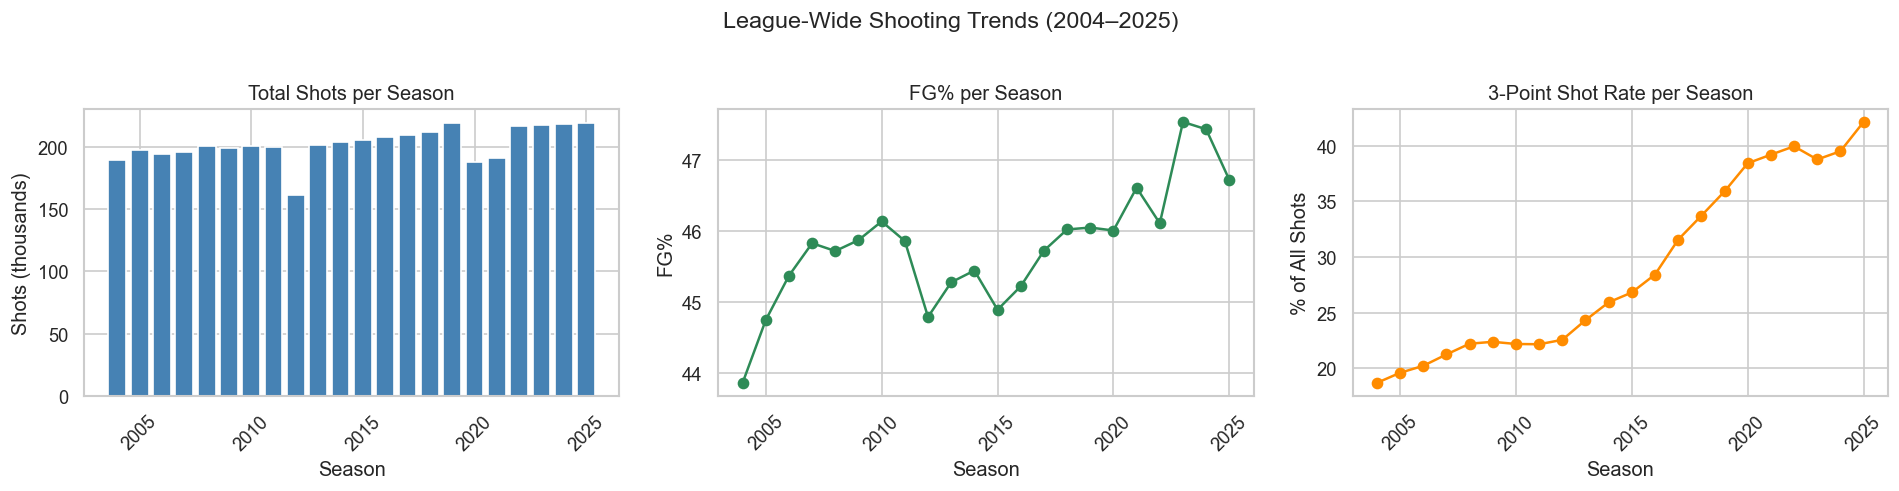

In [9]:
season_stats = (
    df.groupby("SEASON_1")
    .agg(
        total_shots=("SHOT_MADE", "count"),
        fg_pct=("SHOT_MADE", "mean"),
        three_pt_rate=("IS_3PT", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(season_stats["SEASON_1"], season_stats["total_shots"] / 1000, color="steelblue")
axes[0].set_title("Total Shots per Season")
axes[0].set_ylabel("Shots (thousands)")
axes[0].set_xlabel("Season")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(season_stats["SEASON_1"], season_stats["fg_pct"] * 100, marker="o", color="seagreen")
axes[1].set_title("FG% per Season")
axes[1].set_ylabel("FG%")
axes[1].set_xlabel("Season")
axes[1].tick_params(axis="x", rotation=45)

axes[2].plot(season_stats["SEASON_1"], season_stats["three_pt_rate"] * 100, marker="o", color="darkorange")
axes[2].set_title("3-Point Shot Rate per Season")
axes[2].set_ylabel("% of All Shots")
axes[2].set_xlabel("Season")
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("League-Wide Shooting Trends (2004–2025)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Shot distribution by court zone

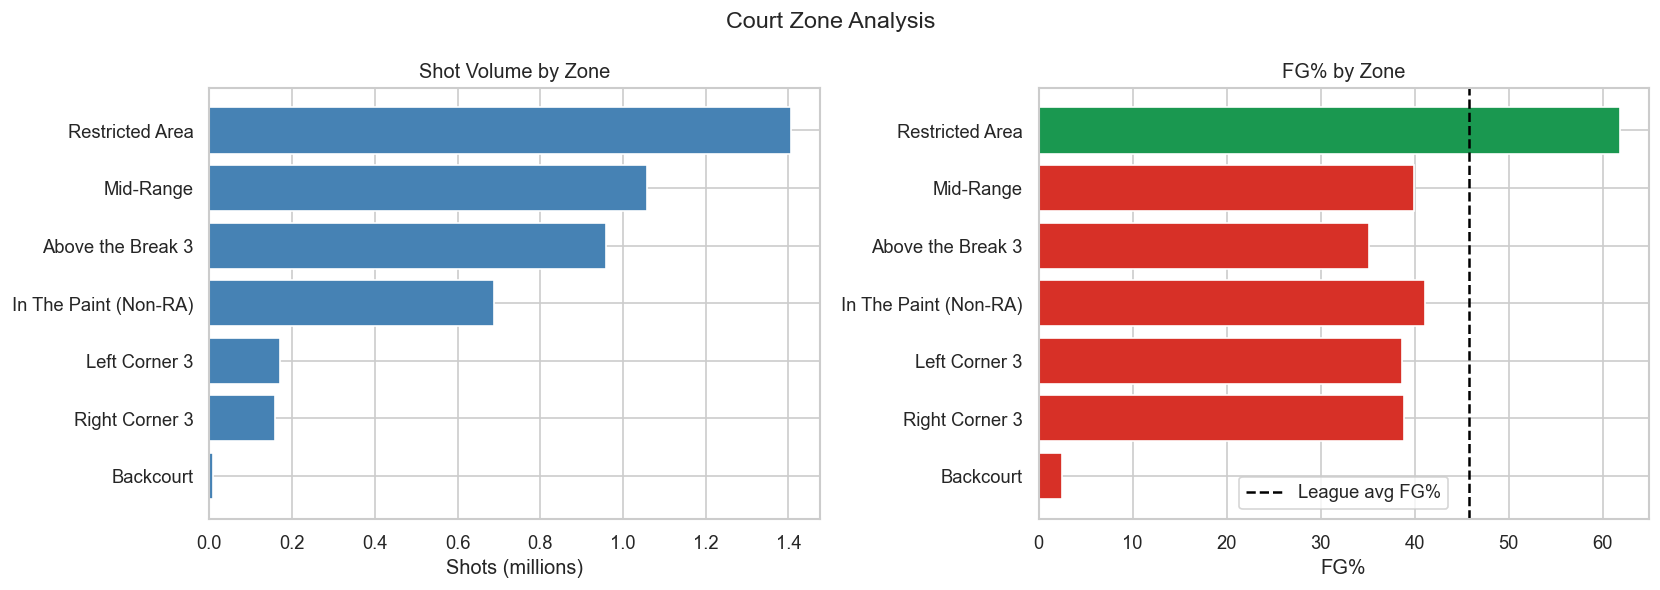

In [10]:
zone_stats = (
    df.groupby("BASIC_ZONE", observed=True)
    .agg(count=("SHOT_MADE", "count"), fg_pct=("SHOT_MADE", "mean"))
    .sort_values("count", ascending=True)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(zone_stats["BASIC_ZONE"], zone_stats["count"] / 1e6, color="steelblue")
axes[0].set_title("Shot Volume by Zone")
axes[0].set_xlabel("Shots (millions)")

colors = ["#d73027" if x < 0.43 else "#1a9850" for x in zone_stats["fg_pct"]]
axes[1].barh(zone_stats["BASIC_ZONE"], zone_stats["fg_pct"] * 100, color=colors)
axes[1].axvline(df["SHOT_MADE"].mean() * 100, color="black", linestyle="--", label="League avg FG%")
axes[1].set_title("FG% by Zone")
axes[1].set_xlabel("FG%")
axes[1].legend()

plt.suptitle("Court Zone Analysis", fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Shot distance distribution

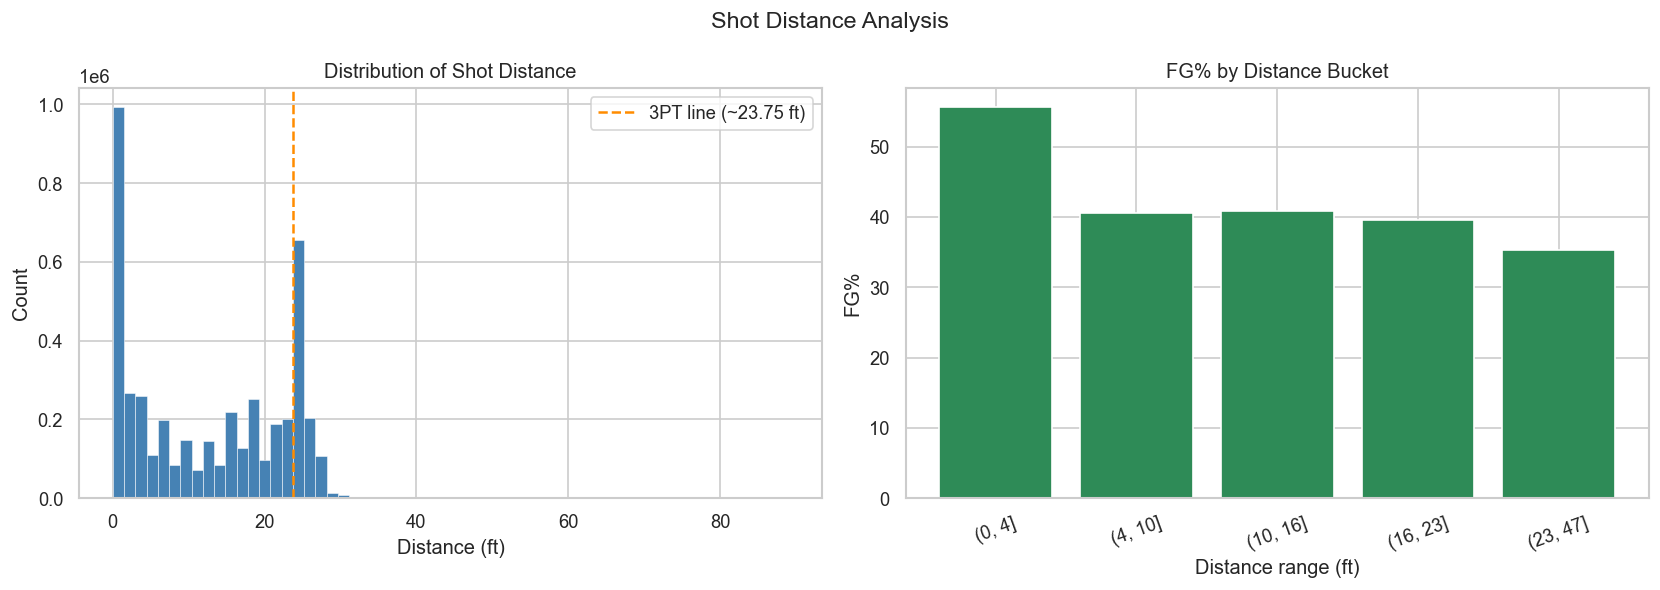

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["SHOT_DISTANCE"], bins=60, color="steelblue", edgecolor="white", linewidth=0.3
)
axes[0].axvline(23.75, color="darkorange", linestyle="--", label="3PT line (~23.75 ft)")
axes[0].set_title("Distribution of Shot Distance")
axes[0].set_xlabel("Distance (ft)")
axes[0].set_ylabel("Count")
axes[0].legend()

dist_bins = pd.cut(df["SHOT_DISTANCE"], bins=[0, 4, 10, 16, 23, 47])
made_by_dist = df.groupby(dist_bins, observed=True)["SHOT_MADE"].mean() * 100
made_by_dist.index = [str(i) for i in made_by_dist.index]
axes[1].bar(made_by_dist.index, made_by_dist.values, color="seagreen")
axes[1].set_title("FG% by Distance Bucket")
axes[1].set_xlabel("Distance range (ft)")
axes[1].set_ylabel("FG%")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Shot Distance Analysis", fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Shot heatmap on the half-court

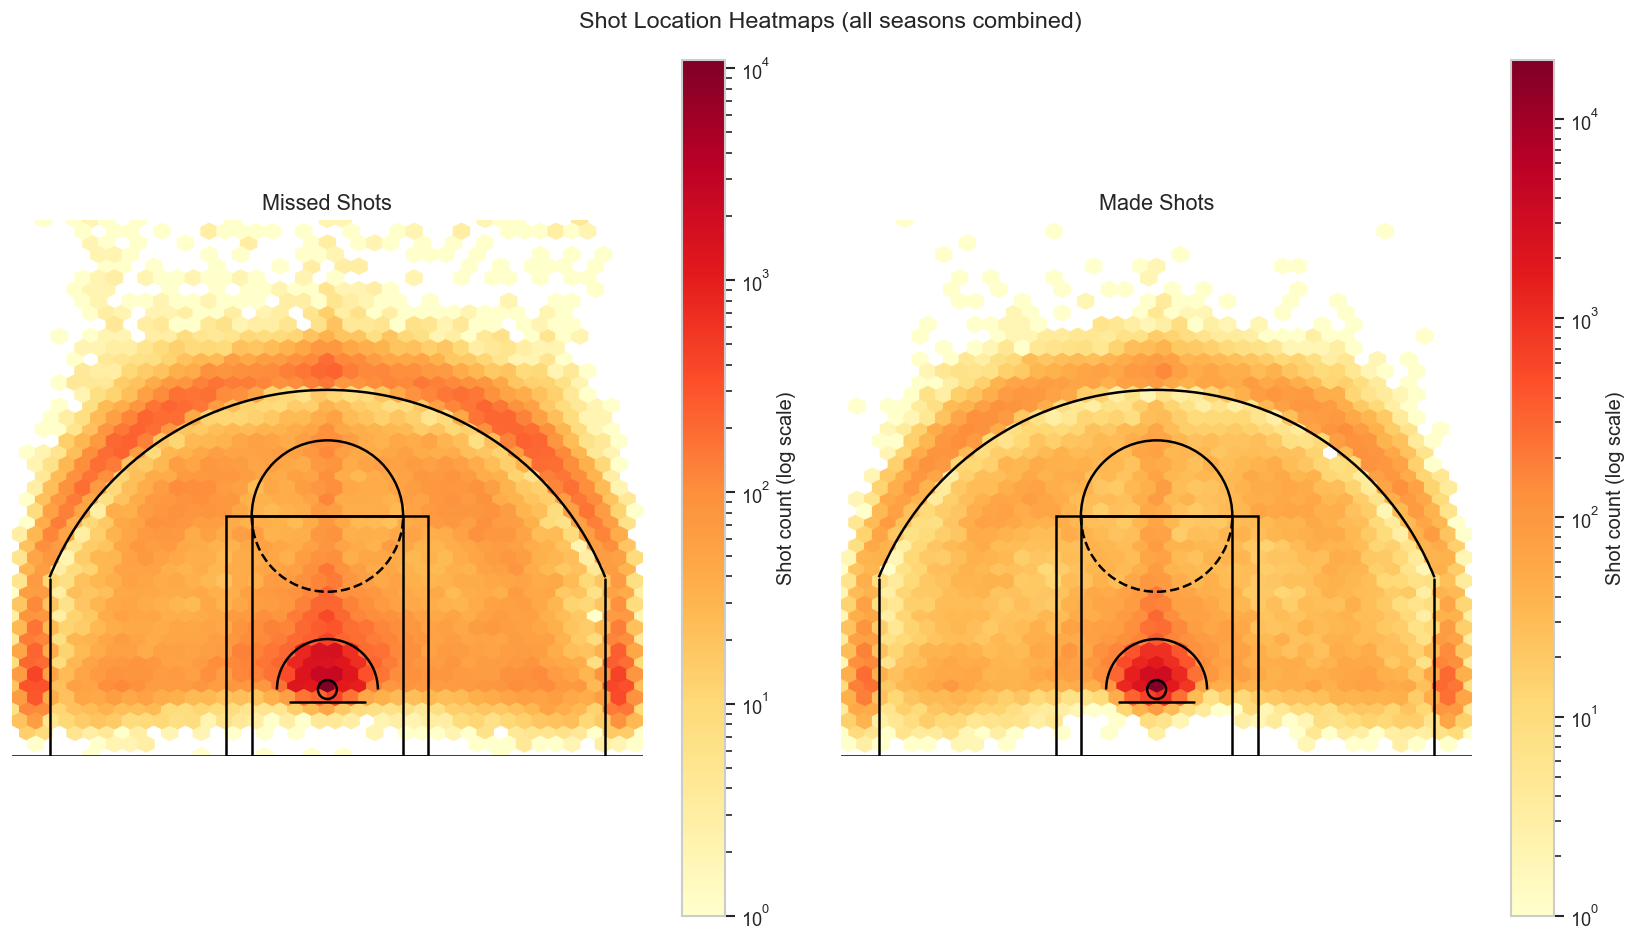

In [12]:
def draw_court(ax, color="black", lw=1.5):
    """Draws an NBA half-court diagram on the given axes.

    In the NBA shot-location data LOC_Y=0 is the baseline and the basket
    sits at LOC_Y≈5.25 ft, so every court element is offset by +5.25 on the
    y-axis relative to the basket-at-origin convention.
    """

    Y0 = 5.25  # basket y-coordinate in the data frame

    # Hoop
    hoop = Circle((0, Y0), radius=0.75, linewidth=lw, color=color, fill=False)
    # Backboard
    ax.plot([-3, 3], [Y0 - 1, Y0 - 1], linewidth=lw, color=color)
    # Baseline
    ax.plot([-25, 25], [0, 0], linewidth=lw, color=color)
    # Paint (key)
    outer_box = plt.Rectangle((-8, 0), 16, 19, linewidth=lw, color=color, fill=False)
    inner_box = plt.Rectangle((-6, 0), 12, 19, linewidth=lw, color=color, fill=False)
    # Free throw arcs (center = basket x, free-throw line y = Y0 + 13.75)
    ft_y = Y0 + 13.75
    top_free_throw = Arc((0, ft_y), 12, 12, theta1=0, theta2=180, linewidth=lw, color=color)
    bottom_free_throw = Arc((0, ft_y), 12, 12, theta1=180, theta2=0, linewidth=lw, color=color, linestyle="dashed")
    # Restricted area (centred on basket)
    restricted = Arc((0, Y0), 8, 8, theta1=0, theta2=180, linewidth=lw, color=color)
    # 3-point line (arc centred on basket; corner segments from baseline)
    corner_three_a = ax.plot([-22, -22], [0, Y0 + 8.75], linewidth=lw, color=color)
    corner_three_b = ax.plot([22, 22], [0, Y0 + 8.75], linewidth=lw, color=color)
    three_arc = Arc((0, Y0), 47.5, 47.5, theta1=22, theta2=158, linewidth=lw, color=color)

    for element in [hoop, outer_box, inner_box, restricted]:
        ax.add_patch(element)
    for element in [top_free_throw, bottom_free_throw, three_arc]:
        ax.add_patch(element)


# Sample for performance
sample = df.sample(n=min(200_000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, made, title in zip(
    axes,
    [0, 1],
    ["Missed Shots", "Made Shots"],
):
    sub = sample[sample["SHOT_MADE"] == made]
    hb = ax.hexbin(
        sub["LOC_X"],
        sub["LOC_Y"],
        gridsize=40,
        cmap="YlOrRd",
        mincnt=1,
        norm=matplotlib.colors.LogNorm(),
        extent=[-25, 25, 0, 42.5],
    )
    fig.colorbar(hb, ax=ax, label="Shot count (log scale)")
    draw_court(ax)
    ax.set_xlim(-25, 25)
    ax.set_ylim(0, 42.5)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=13)
    ax.axis("off")

plt.suptitle("Shot Location Heatmaps (all seasons combined)", fontsize=14)
plt.tight_layout()
plt.show()

### 4.5 FG% by position

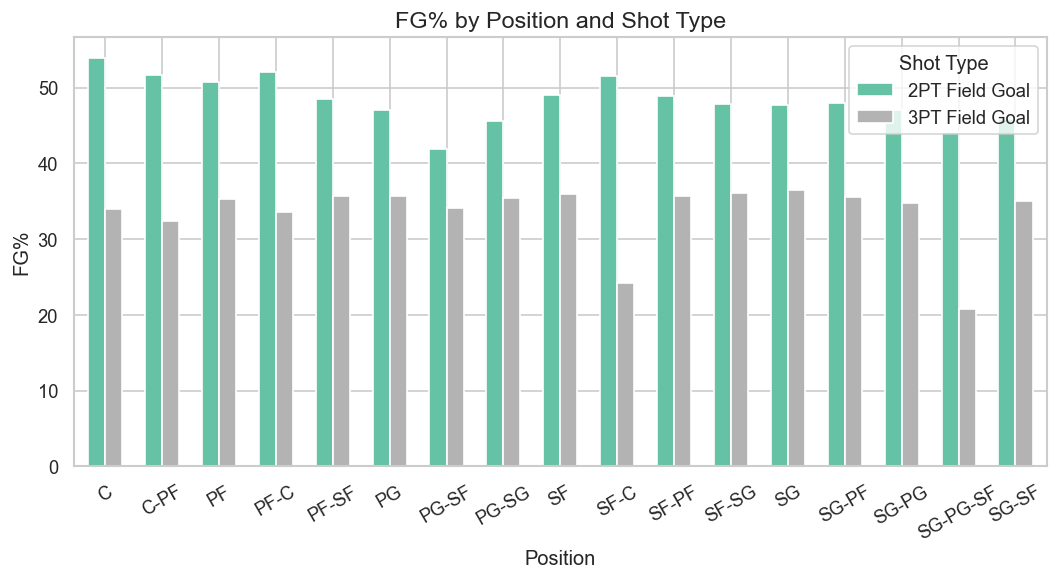

In [13]:
pos_stats = (
    df.groupby(["POSITION", "SHOT_TYPE"], observed=True)
    .agg(fg_pct=("SHOT_MADE", "mean"), count=("SHOT_MADE", "count"))
    .reset_index()
)

pivot = pos_stats.pivot(index="POSITION", columns="SHOT_TYPE", values="fg_pct") * 100

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind="bar", ax=ax, width=0.6, colormap="Set2")
ax.set_title("FG% by Position and Shot Type", fontsize=14)
ax.set_xlabel("Position")
ax.set_ylabel("FG%")
ax.legend(title="Shot Type")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 4.6 In-game timing: shots and accuracy by quarter & game minute

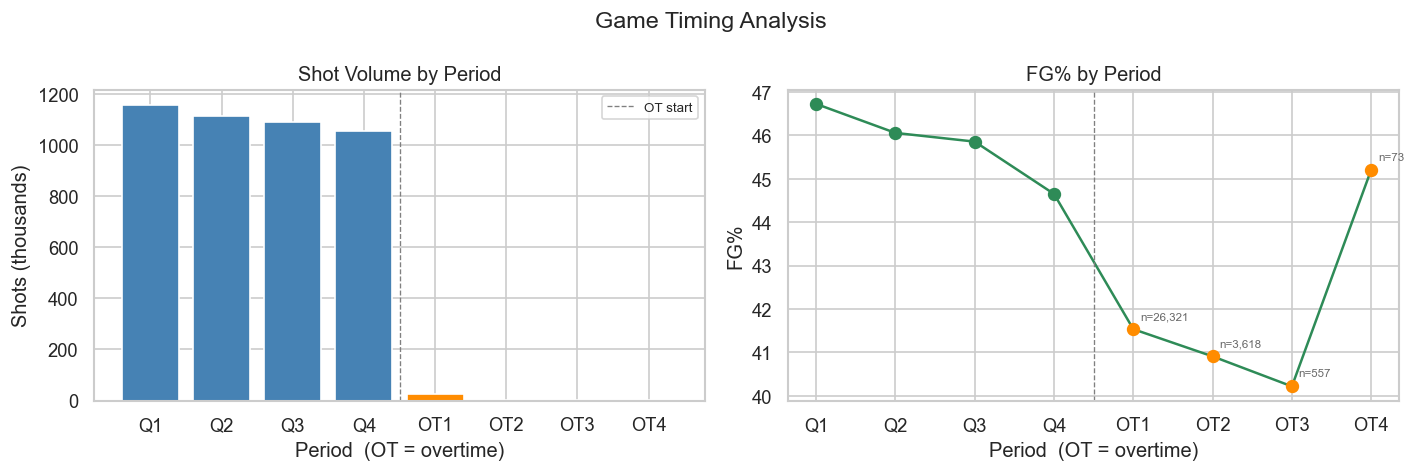

In [14]:
quarter_stats = (
    df.groupby("QUARTER")
    .agg(count=("SHOT_MADE", "count"), fg_pct=("SHOT_MADE", "mean"))
    .reset_index()
)

def quarter_label(q):
    return f"Q{q}" if q <= 4 else f"OT{q - 4}"

labels = [quarter_label(q) for q in quarter_stats["QUARTER"]]
x = range(len(labels))

# colour: regular quarters in blue, OT periods in orange
bar_colors = ["steelblue" if q <= 4 else "darkorange" for q in quarter_stats["QUARTER"]]
dot_colors = ["seagreen" if q <= 4 else "darkorange" for q in quarter_stats["QUARTER"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x, quarter_stats["count"] / 1000, color=bar_colors)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels)
axes[0].set_title("Shot Volume by Period")
axes[0].set_xlabel("Period  (OT = overtime)")
axes[0].set_ylabel("Shots (thousands)")
axes[0].axvline(3.5, color="grey", linestyle="--", linewidth=0.8, label="OT start")
axes[0].legend(fontsize=8)

axes[1].plot(list(x), quarter_stats["fg_pct"] * 100, marker="o", color="seagreen")
for xi, yi, c in zip(x, quarter_stats["fg_pct"] * 100, dot_colors):
    axes[1].plot(xi, yi, marker="o", color=c, markersize=7)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels)
axes[1].set_title("FG% by Period")
axes[1].set_xlabel("Period  (OT = overtime)")
axes[1].set_ylabel("FG%")
axes[1].axvline(3.5, color="grey", linestyle="--", linewidth=0.8)

# annotate OT sample sizes so the noisy FG% is contextualised
for xi, row in zip(x, quarter_stats.itertuples()):
    if row.QUARTER > 4:
        axes[1].annotate(
            f"n={row.count:,}",
            xy=(xi, row.fg_pct * 100),
            xytext=(4, 6),
            textcoords="offset points",
            fontsize=7,
            color="dimgray",
        )

plt.suptitle("Game Timing Analysis", fontsize=14)
plt.tight_layout()
plt.show()

### 4.7 Top 20 most prolific shooters (all-time)

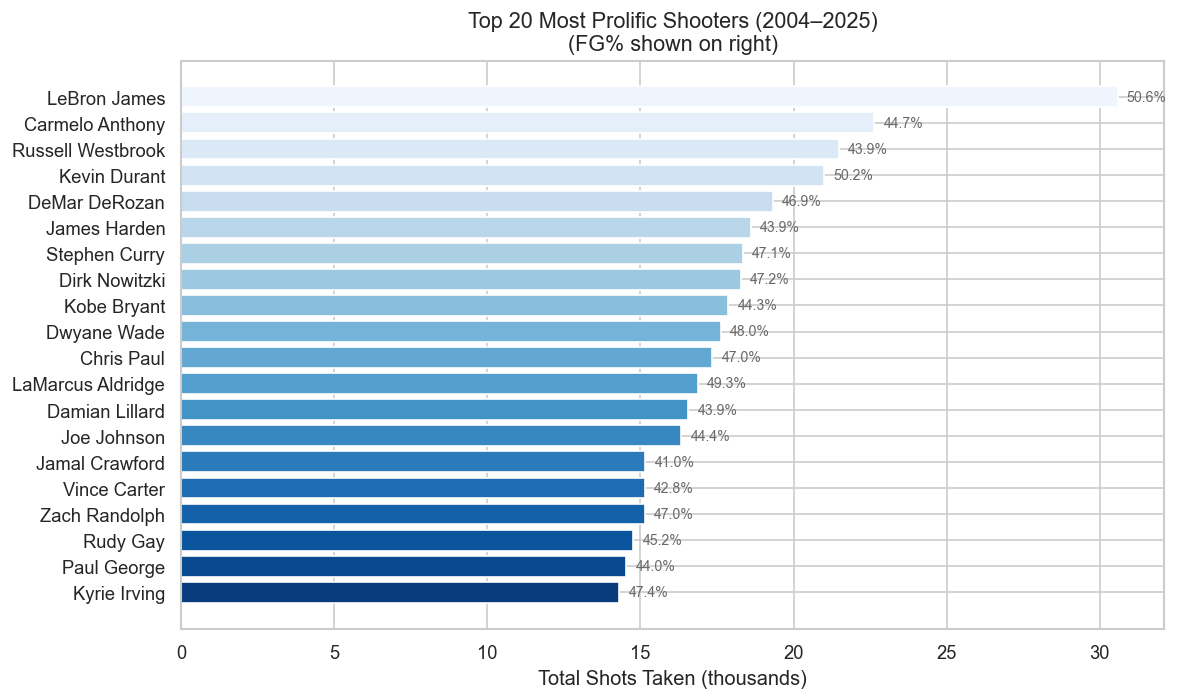

In [ ]:
player_stats = (
    df.groupby("PLAYER_NAME", observed=True)
    .agg(shots=("SHOT_MADE", "count"), fg_pct=("SHOT_MADE", "mean"))
    .nlargest(20, "shots")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    player_stats["PLAYER_NAME"][::-1],
    player_stats["shots"][::-1] / 1000,
    color=sns.color_palette("Blues_r", 20),
)
for bar, pct in zip(bars, player_stats["fg_pct"][::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{pct*100:.1f}%",
        va="center", fontsize=8.5, color="dimgray"
    )
ax.set_title("Top 20 Most Prolific Shooters (2004-2025)\n(FG% shown on right)", fontsize=13)
ax.set_xlabel("Total Shots Taken (thousands)")
plt.tight_layout()
plt.show()

### 4.8 Zone shot-mix shift: 2004 vs 2025

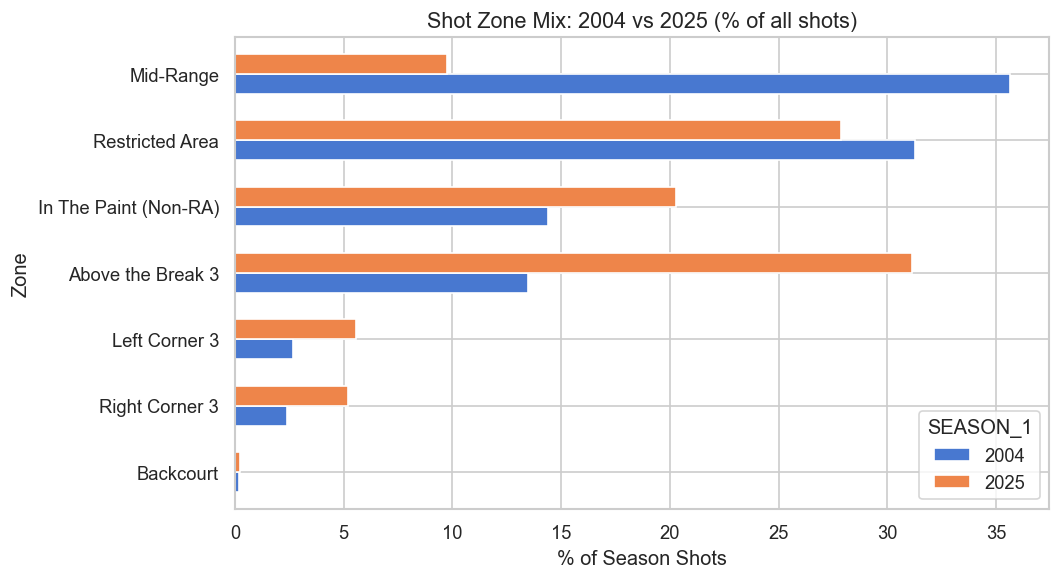

In [16]:
years = [2004, 2025]
zone_mix = (
    df[df["SEASON_1"].isin(years)]
    .groupby(["SEASON_1", "BASIC_ZONE"], observed=True)["SHOT_MADE"]
    .count()
    .groupby(level=0, group_keys=False)
    .apply(lambda x: x / x.sum() * 100)
    .reset_index(name="pct")
)

pivot_mix = zone_mix.pivot(index="BASIC_ZONE", columns="SEASON_1", values="pct").fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
pivot_mix.sort_values(2004, ascending=True).plot(kind="barh", ax=ax, width=0.6)
ax.set_title("Shot Zone Mix: 2004 vs 2025 (% of all shots)", fontsize=13)
ax.set_xlabel("% of Season Shots")
ax.set_ylabel("Zone")
plt.tight_layout()
plt.show()